In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
data = pd.read_csv('UofU 650-05-376 BHA 18 - output data.csv', skiprows=35)
data1 = pd.read_csv("UofU 650-05-438 BHA 30 - output data.csv", skiprows=35)
data1 = data1[data1["Bit Box_ShYpeak(g)"] < 100]
'''data2a = pd.read_csv("BHA 35r1 650-05-551 - output data.csv", skiprows=35)
data2b = pd.read_csv("BHA 35r2 650-05-551 - output data.csv", skiprows=35)
data2 = pd.concat([data2a, data2b], axis=0)'''

'data2a = pd.read_csv("BHA 35r1 650-05-551 - output data.csv", skiprows=35)\ndata2b = pd.read_csv("BHA 35r2 650-05-551 - output data.csv", skiprows=35)\ndata2 = pd.concat([data2a, data2b], axis=0)'

In [32]:
dataframes = [data,data1,]
for x in range(len(dataframes)):
    dataframes[x]["Augmented RPM(RPM)"] = np.where(
    dataframes[x]["Surface_GC_Rotating(bool)"] == 1,
    dataframes[x]["Surface_Flow In(GPM)"] * 0.242 + dataframes[x]["Surface_Top Drive RPM(RPM)"],
    dataframes[x]["Surface_Flow In(GPM)"] * 0.242
    )
    dataframes[x] = dataframes[x][(dataframes[x]["Surface_Weight on Bit(klbs)"] >= 0) & (dataframes[x]["Surface_Weight on Bit(klbs)"] <= 100)]
    dataframes[x] = dataframes[x].dropna(subset=["Bit Box_ShYpeak(g)", "Surface_Weight on Bit(klbs)", "Augmented RPM(RPM)"])
    dataframes[x] = dataframes[x][(dataframes[x]["Augmented RPM(RPM)"] <= 260)]
data, data1 = dataframes

In [33]:
dataDrilling = data[data["Surface_GC_OnBottom(bool)"] == 1]
dataDrilling1 = data1[data1["Surface_GC_OnBottom(bool)"] == 1]
#dataDrilling2 = data2[data2["Surface_GC_OnBottom(bool)"] == 1]
#dataDrilling3 = data3[data3["Surface_GC_OnBottom(bool)"] == 1]
#-----------------------------------------------------------------------------
dataRotating = dataDrilling[dataDrilling["Surface_GC_Rotating(bool)"] == 1]
dataRotating1 = dataDrilling1[dataDrilling1["Surface_GC_Rotating(bool)"] == 1]
#dataRotating2 = dataDrilling2[dataDrilling2["Surface_GC_Rotating(bool)"] == 1]
#dataRotating3 = dataDrilling3[dataDrilling3["Surface_GC_Rotating(bool)"] == 1]

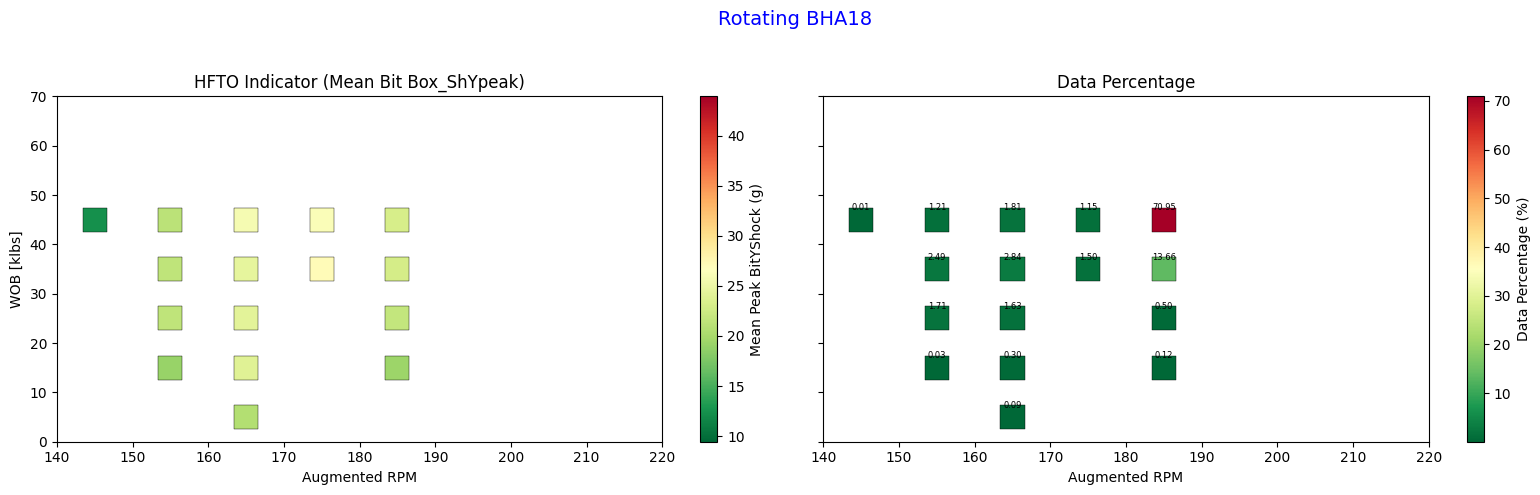

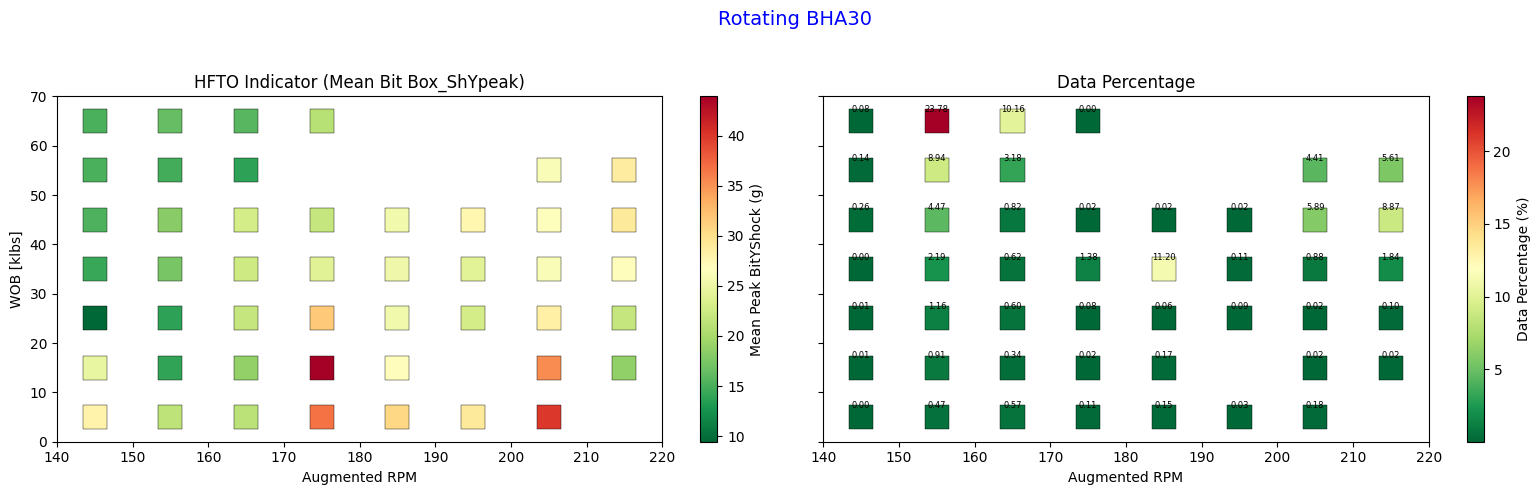

In [34]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Rotating BHA18": dataRotating,
    "Rotating BHA30": dataRotating1,
    #"Rotating BHA35": dataRotating2,
    #"Rotating BHA23": dataRotating3
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = "Bit Box_ShYpeak(g)"

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in states.values())
maxrpm_raw = max(df[rpm_col].max() for df in states.values())

minwob_raw = min(df[wob_col].min() for df in states.values())
maxwob_raw = max(df[wob_col].max() for df in states.values())

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = np.nanmin(all_hfto_vals) if len(all_hfto_vals) else np.nan
hfto_vmax = np.nanmax(all_hfto_vals) if len(all_hfto_vals) else np.nan

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14, color="blue")

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShYpeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitYShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)
